<a href="https://colab.research.google.com/github/bemakerorg/AIoT_Book_II_RF/blob/main/AIOT_RF_Book_ES_29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Descrizione Cella 1:**

Questa cella gestisce l'ambiente di sviluppo verificando e installando le versioni specifiche delle librerie necessarie. Utilizza blocchi try-except per gestire librerie mancanti e forza versioni compatibili specifiche per garantire la riproducibilità dell'esperimento.

In [1]:
# CELLA 1 - IMPORTAZIONE LIBRERIE E PACCHETTI NECESSARI
# Verifica delle versioni delle librerie e installazione pacchetti compatibili
import sys  # Libreria per accedere alle informazioni del sistema

# Verifica versione Python (richiesta >= 3.7)
print(f"Versione Python: {sys.version}")      # Stampa versione Python corrente

# Installazione e import librerie principali con versioni compatibili
try:
    import tensorflow as tf                   # Importa TensorFlow per deep learning
    print(f"TensorFlow: {tf.__version__}")    # Stampa versione TensorFlow
    if tf.__version__ != '2.19.0':            # Verifica se versione non è 2.19.0
        !pip install tensorflow==2.19.0       # Installa versione specifica
        import tensorflow as tf               # Re-importa dopo installazione
except ImportError:                           # Se TensorFlow non è installato
   !pip install tensorflow==2.19.0            # Installa TensorFlow versione 2.19.0
   import tensorflow as tf                    # Importa dopo installazione

try:
    import numpy as np                        # Importa NumPy per calcoli numerici
    print(f"NumPy: {np.__version__}")         # Stampa versione NumPy
    if np.__version__ != '2.0.2':             # Verifica se versione non è 2.0.2
        !pip install numpy==2.0.2             # Installa versione specifica
        import numpy as np                    # Re-importa dopo installazione
except ImportError:                           # Se NumPy non è installato
    !pip install numpy==2.0.2                 # Installa NumPy versione 2.0.2
    import numpy as np                        # Importa dopo installazione

# ... continua per tutte le altre librerie (matplotlib, seaborn, sklearn)
try:
    import matplotlib.pyplot as plt
    import matplotlib
    print(f"Matplotlib: {matplotlib.__version__}")
    if matplotlib.__version__ != '3.10.0':    # Verifica compatibilità Matplotlib
        !pip install matplotlib==3.10.0
        import matplotlib.pyplot as plt
except ImportError:
    !pip install matplotlib==3.10.0           # Installa Matplotlib se mancante
    import matplotlib.pyplot as plt

try:
    import seaborn as sns
    print(f"Seaborn: {sns.__version__}")
    if sns.__version__ != '0.13.2':           # Verifica compatibilità Seaborn
        !pip install seaborn==0.13.2
        import seaborn as sns
except ImportError:
    !pip install seaborn==0.13.2              # Installa Seaborn se mancante
    import seaborn as sns

try:
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
    import sklearn
    print(f"Scikit-learn: {sklearn.__version__}")
    if sklearn.__version__ != '1.6.1':        # Verifica compatibilità Scikit-learn
        !pip install scikit-learn==1.6.1
        from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
except ImportError:
    !pip install scikit-learn==1.6.1          # Installa Scikit-learn se mancante
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Import aggiuntivi per il progetto VAE
from tensorflow.keras.layers import Input, Dense, Lambda, Layer   # Layer per costruire il VAE
from tensorflow.keras.models import Model                         # Classe Model per creare modelli
from tensorflow.keras.losses import mse, binary_crossentropy      # Funzioni di loss
from tensorflow.keras import backend as K                         # Backend Keras per operazioni custom
import warnings                                                   # Libreria per gestire warning
warnings.filterwarnings('ignore')                                 # Sopprime warning non critici

print("✅ Tutte le librerie sono state verificate e installate correttamente!")  # Conferma completamento

Versione Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
TensorFlow: 2.19.0
NumPy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
Scikit-learn: 1.6.1
✅ Tutte le librerie sono state verificate e installate correttamente!


## **Descrizione Cella 2:**

Gestisce il caricamento dei due dataset (Fashion MNIST come dati normali, MNIST digits per creare anomalie artificiali), applica preprocessing standard (normalizzazione 0-1, reshape da 28x28 a vettore 784), e seleziona casualmente 10 campioni anomali per il test.

In [2]:
# CELLA 2 - CARICAMENTO E PREPROCESSING DATI
# Caricamento dataset Fashion MNIST (dati normali) e MNIST digits (anomalie)
print("📥 Caricamento dei dataset...")  # Messaggio informativo

# Caricamento Fashion MNIST - useremo questo come dati "normali"
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = tf.keras.datasets.fashion_mnist.load_data()  # Carica dataset Fashion MNIST

# Caricamento MNIST digits - useremo alcuni di questi come "anomalie"
(x_train_digits, y_train_digits), (x_test_digits, y_test_digits) = tf.keras.datasets.mnist.load_data()  # Carica dataset MNIST digits

print(f"Fashion MNIST - Training: {x_train_fashion.shape}, Test: {x_test_fashion.shape}")  # Stampa dimensioni Fashion MNIST
print(f"MNIST Digits - Training: {x_train_digits.shape}, Test: {x_test_digits.shape}")  # Stampa dimensioni MNIST digits

# Preprocessing dei dati
print("\n🔄 Preprocessing dei dati...")  # Messaggio informativo preprocessing

# Normalizzazione valori pixel tra 0 e 1
x_train_fashion = x_train_fashion.astype('float32') / 255.0  # Converte in float32 e normalizza [0,1]
x_test_fashion = x_test_fashion.astype('float32') / 255.0    # Normalizza test set Fashion MNIST
x_train_digits = x_train_digits.astype('float32') / 255.0    # Normalizza training set MNIST digits
x_test_digits = x_test_digits.astype('float32') / 255.0      # Normalizza test set MNIST digits

# Reshape per rendere i dati compatibili con il VAE (flatten delle immagini 28x28 -> 784)
original_dim = 784  # Definisce dimensione input (28 * 28 pixels)
x_train_fashion = x_train_fashion.reshape((len(x_train_fashion), original_dim))  # Flatten training Fashion
x_test_fashion = x_test_fashion.reshape((len(x_test_fashion), original_dim))     # Flatten test Fashion
x_train_digits = x_train_digits.reshape((len(x_train_digits), original_dim))     # Flatten training digits
x_test_digits = x_test_digits.reshape((len(x_test_digits), original_dim))        # Flatten test digits

print(f"✅ Dati processati - Dimensione finale: {x_train_fashion.shape[1]} features per immagine")  # Conferma preprocessing

# Selezione di 10 immagini casuali da MNIST digits come anomalie di test
np.random.seed(42)  # Imposta seed per riproducibilità risultati
anomaly_indices = np.random.choice(len(x_test_digits), 10, replace=False)  # Seleziona 10 indici casuali
x_anomalies = x_test_digits[anomaly_indices]  # Estrae le 10 immagini anomale
y_anomalies = y_test_digits[anomaly_indices]  # Estrae etichette corrispondenti

print(f"🎯 Selezionate {len(x_anomalies)} immagini MNIST digits come anomalie")  # Conferma selezione anomalie
print(f"Digit selezionati: {y_anomalies}")  # Mostra quali digit sono stati selezionati

📥 Caricamento dei dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion MNIST - Training: (60000, 28, 28), Test: (10000, 28, 28)
MNIST Digits - Training: (60000, 28, 28), Test: (10000, 28, 28)

🔄 Preprocessing dei dati...
✅ Dati processati - Dimensione finale: 784 features per immagine
🎯 Selezionate 10 immagini MNIST digits come anomalie
Digit selezionati: [6 2 3 7 2 2 3 4 7 6]


## **Descrizione Cella 3:**

Fornisce una visualizzazione esplorativa dei dati creando una griglia comparativa tra campioni normali (Fashion MNIST) e anomalie (MNIST digits). Include statistiche descrittive per verificare la corretta normalizzazione e comprendere la distribuzione dei valori.

👕 Campioni Fashion MNIST (Dati Normali):
🔢 Campioni MNIST Digits (Anomalie):


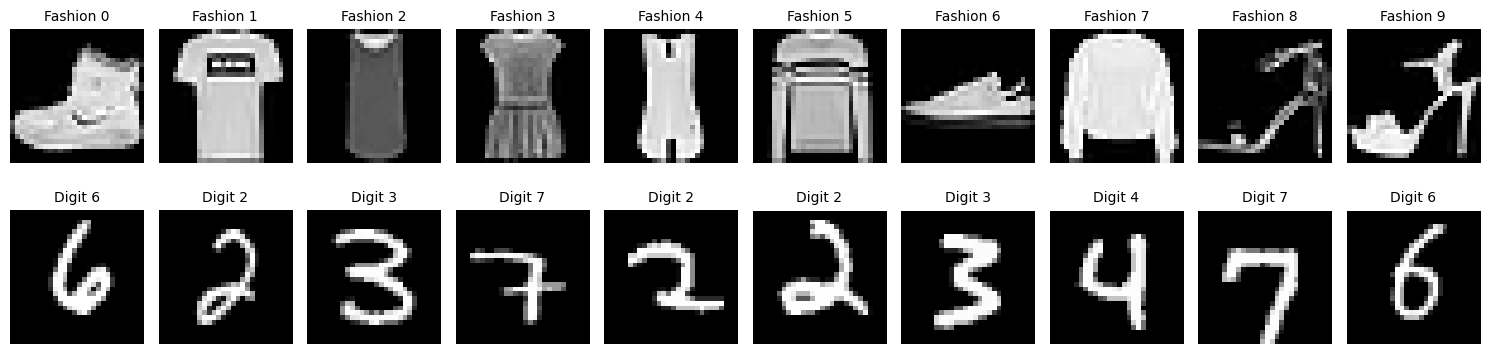


📊 Statistiche Dataset:
Fashion MNIST Training - Min: 0.000, Max: 1.000, Mean: 0.286
Fashion MNIST Test - Min: 0.000, Max: 1.000, Mean: 0.287
MNIST Digits Anomalie - Min: 0.000, Max: 1.000, Mean: 0.127


In [3]:
# CELLA 3 - VISUALIZZAZIONE DATI
# Visualizzazione campioni dei dati normali e anomali
fig, axes = plt.subplots(2, 10, figsize=(15, 4))  # Crea griglia 2x10 per visualizzazione

# Visualizzazione 10 campioni Fashion MNIST (dati normali)
print("👕 Campioni Fashion MNIST (Dati Normali):")                     # Intestazione per dati normali
for i in range(10):                                                     # Ciclo per 10 campioni
    axes[0, i].imshow(x_train_fashion[i].reshape(28, 28), cmap='gray')  # Mostra immagine 28x28 in scala grigi
    axes[0, i].set_title(f'Fashion {i}', fontsize=10)                   # Imposta titolo con indice
    axes[0, i].axis('off')                                              # Rimuove assi per chiarezza visiva

# Visualizzazione 10 campioni MNIST digits (anomalie)
print("🔢 Campioni MNIST Digits (Anomalie):")                            # Intestazione per anomalie
for i in range(10):                                                       # Ciclo per 10 anomalie
    axes[1, i].imshow(x_anomalies[i].reshape(28, 28), cmap='gray')        # Mostra anomalia 28x28 in scala grigi
    axes[1, i].set_title(f'Digit {y_anomalies[i]}', fontsize=10)          # Titolo con etichetta digit
    axes[1, i].axis('off')  # Rimuove assi per chiarezza

plt.tight_layout()                                                      # Ottimizza spaziatura layout
plt.show()                                                              # Mostra il grafico

# Statistiche descrittive dei dataset
print(f"\n📊 Statistiche Dataset:")                                                                                                         # Intestazione statistiche
print(f"Fashion MNIST Training - Min: {x_train_fashion.min():.3f}, Max: {x_train_fashion.max():.3f}, Mean: {x_train_fashion.mean():.3f}")   # Statistiche Fashion training
print(f"Fashion MNIST Test - Min: {x_test_fashion.min():.3f}, Max: {x_test_fashion.max():.3f}, Mean: {x_test_fashion.mean():.3f}")          # Statistiche Fashion test
print(f"MNIST Digits Anomalie - Min: {x_anomalies.min():.3f}, Max: {x_anomalies.max():.3f}, Mean: {x_anomalies.mean():.3f}")                # Statistiche anomalie

## **Descrizione Cella 4:**

Costruisce l'architettura completa del VAE implementando: encoder (784→256→2), decoder (2→256→784) e il reparameterization trick. Include un layer personalizzato per gestire la KL divergence loss. L'architettura è progettata per apprendimento non supervisionato su Fashion MNIST.

In [4]:
# CELLA 4 - COSTRUZIONE ARCHITETTURA VAE
# Definizione dell'architettura Variational Auto Encoder - Versione Corretta
print("🏗️ Costruzione architettura VAE...")  # Messaggio iniziale costruzione

# Parametri del modello
original_dim = 784      # Dimensione input (28x28 pixels flattened)
latent_dim = 2          # Dimensione spazio latente (2D per visualizzazione)
intermediate_dim = 256  # Dimensione layer intermedio (bottleneck)

# Definizione Encoder
print("🔹 Costruzione Encoder...")  # Messaggio costruzione encoder
inputs = Input(shape=(original_dim,), name='encoder_input')  # Layer input con forma (784,)
h = Dense(intermediate_dim, activation='relu', name='encoder_hidden')(inputs)  # Layer hidden con 256 neuroni ReLU

# Layer per media e log-varianza dello spazio latente
z_mean = Dense(latent_dim, name='z_mean')(h)      # Layer per media distribuzione latente
z_log_var = Dense(latent_dim, name='z_log_var')(h)  # Layer per log-varianza distribuzione latente

# Sampling function - implementa il "reparameterization trick"
def sampling(args):
    """Campiona punti dalla distribuzione latente usando il reparameterization trick"""
    z_mean, z_log_var = args  # Estrae media e log-varianza dagli argomenti
    batch = tf.shape(z_mean)[0]  # Ottiene dimensione batch dinamicamente
    dim = tf.shape(z_mean)[1]   # Ottiene dimensione spazio latente
    epsilon = tf.random.normal(shape=(batch, dim))  # Genera rumore gaussiano standard N(0,1)
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon  # Applica reparameterization trick

# Layer di sampling
z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])  # Applica sampling con Lambda layer

# Creazione modello encoder
encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')  # Encoder con 3 output
print(f"✅ Encoder creato con {encoder.count_params()} parametri")  # Conta e mostra parametri

# Definizione Decoder
print("🔹 Costruzione Decoder...")  # Messaggio costruzione decoder
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')  # Input dal spazio latente (2D)
h_decoded = Dense(intermediate_dim, activation='relu', name='decoder_hidden')(latent_inputs)  # Layer hidden decoder
outputs = Dense(original_dim, activation='sigmoid', name='decoder_output')(h_decoded)  # Output con sigmoid [0,1]

# Creazione modello decoder
decoder = Model(latent_inputs, outputs, name='decoder')  # Decoder completo
print(f"✅ Decoder creato con {decoder.count_params()} parametri")  # Conta e mostra parametri decoder

# Custom layer per aggiungere KL divergence loss
class KLDivergenceLayer(Layer):
    """Aggiunge la KL divergence loss al modello."""

    def call(self, inputs):
        """Metodo call del layer personalizzato"""
        z_mean, z_log_var = inputs  # Estrae media e log-varianza
        kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)  # Calcola KL divergence
        self.add_loss(K.mean(kl_loss))  # Aggiunge loss al modello
        return inputs  # Ritorna input inalterati (pass-through layer)

# Connessione Encoder + Decoder = VAE completo
print("🔹 Assemblaggio VAE completo...")  # Messaggio assemblaggio finale
z_mean, z_log_var = KLDivergenceLayer()([z_mean, z_log_var])  # Applica KL divergence layer
outputs = decoder(z)  # Collega decoder al sample z dall'encoder

# Definizione modello VAE completo
vae = Model(inputs, outputs, name='vae')  # VAE completo input->output
print(f"✅ VAE completo creato con {vae.count_params()} parametri totali")  # Conta parametri totali

# Visualizzazione architettura
vae.summary()  # Mostra struttura dettagliata del modello

🏗️ Costruzione architettura VAE...
🔹 Costruzione Encoder...
✅ Encoder creato con 201988 parametri
🔹 Costruzione Decoder...
✅ Decoder creato con 202256 parametri
🔹 Assemblaggio VAE completo...
✅ VAE completo creato con 404244 parametri totali


Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_hidden      │ (None, 256)       │    200,960 │ encoder_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ encoder_hidden[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ encoder_hidden[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 784)       │    202,256 │ z[0][0]           │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 404,244 (1.54 MB)

 Trainable params: 404,244 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

## **Descrizione Cella 5:**


Definisce la loss function del VAE implementando solo la reconstruction loss (MSE scalata), mentre la KL divergence è gestita automaticamente dal layer personalizzato. Compila il modello con ottimizzatore Adam e metriche di monitoraggio.

In [5]:
# CELLA 5 - DEFINIZIONE LOSS FUNCTION
# Definizione della loss function per VAE (ELBO - Evidence Lower BOund) - Versione Corretta
print("📐 Definizione Loss Function VAE...")  # Messaggio definizione loss

# La reconstruction loss è calcolata separatamente
def reconstruction_loss_fn(y_true, y_pred):
    """Reconstruction loss (Mean Squared Error)"""
    reconstruction_loss = mse(y_true, y_pred)    # Calcola Mean Squared Error tra input e output
    reconstruction_loss *= original_dim           # Scala per dimensione input (784)
    return K.mean(reconstruction_loss)  # Ritorna media della loss su batch

# Compilazione modello con loss personalizzata
print("⚙️ Compilazione modello...")  # Messaggio compilazione
vae.compile(
    optimizer='adam',           # Ottimizzatore Adam (learning rate adattivo)
    loss=reconstruction_loss_fn, # Solo reconstruction loss qui, KL è aggiunta nel modello
    metrics=['mse']            # Metrica aggiuntiva MSE per monitoraggio
)

print("✅ Modello compilato e pronto per training!")  # Conferma compilazione completata

📐 Definizione Loss Function VAE...
⚙️ Compilazione modello...
✅ Modello compilato e pronto per training!


## **Descrizione Cella 6:**


Gestisce il processo di training del VAE sui dati Fashion MNIST implementando strategie di ottimizzazione (early stopping, learning rate scheduling) e monitoraggio delle performance. Il training è non supervisionato (input=output).

In [6]:
# CELLA 6 - ADDESTRAMENTO VAE
# Training del VAE sui dati Fashion MNIST (solo dati normali)
print("🚀 Inizio training VAE su Fashion MNIST...")  # Messaggio inizio training

# Parametri di training
epochs = 50               # Numero massimo di epoche di training
batch_size = 128          # Dimensione batch per training (campioni per aggiornamento)
validation_split = 0.2    # 20% dati per validazione (split automatico)

# Callback per monitoraggio training
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # Import callback

# Early stopping per evitare overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',         # Monitora validation loss per decisioni stopping
    patience=10,                # Ferma se non migliora per 10 epoche consecutive
    restore_best_weights=True   # Ripristina pesi della miglior epoca
)

# Riduzione learning rate se training si blocca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',         # Monitora validation loss per riduzione LR
    factor=0.5,                 # Riduce LR del 50% quando attivato
    patience=5,                 # Attende 5 epoche prima di ridurre LR
    min_lr=1e-6                 # Learning rate minimo raggiungibile
)

print(f"🎯 Parametri training: {epochs} epoche, batch size {batch_size}")  # Riepilogo parametri
print(f"📊 Dataset: {len(x_train_fashion)} campioni training + validazione")  # Dimensione dataset

# Avvio training
history = vae.fit(
    x_train_fashion, x_train_fashion,       # Input = Output per autoencoder (unsupervised)
    epochs=epochs,                          # Numero epoche di training
    batch_size=batch_size,                  # Dimensione batch
    validation_split=validation_split,      # Split automatico train/validation
    callbacks=[early_stopping, reduce_lr],  # Callback per ottimizzazione training
    verbose=1,                              # Mostra progresso dettagliato ogni epoca
    shuffle=True                            # Mescola dati ad ogni epoca
)

print("✅ Training completato!")  # Conferma completamento training

🚀 Inizio training VAE su Fashion MNIST...
🎯 Parametri training: 50 epoche, batch size 128
📊 Dataset: 60000 campioni training + validazione
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 55.5622 - mse: 0.0709 - val_loss: 29.6536 - val_mse: 0.0378 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 28.4129 - mse: 0.0362 - val_loss: 26.7263 - val_mse: 0.0341 - learning_rate: 0.0010
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 26.3627 - mse: 0.0336 - val_loss: 25.8083 - val_mse: 0.0329 - learning_rate: 0.0010
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 25.6322 - mse: 0.0327 - val_loss: 25.2690 - val_mse: 0.0322 - learning_rate: 0.0010
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 25.1239 - mse: 0.0320 - val_loss: 24.8677 - val_mse: 0.0317 - learning_rate: 0.0010
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 24.6746 - mse: 0.0315 - val_loss: 24.7691 - val_mse: 0.0316 - learning_rat

## **Descrizione Cella 7:**


Salva il modello addestrato in formato SavedModel di TensorFlow, che include architettura, pesi e configurazione, permettendo riutilizzo futuro e deployment in produzione.

In [7]:
# CELLA 7 - SALVATAGGIO MODELLO VAE
# Salvataggio dell'intero modello VAE in formato SavedModel
vae.export('vae_fashion_mnist_savedmodel')  # Esporta modello in formato SavedModel TensorFlow
print("💾 Modello VAE completo salvato in formato SavedModel nella cartella 'vae_fashion_mnist_savedmodel'")  # Conferma salvataggio

Saved artifact at 'vae_fashion_mnist_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='encoder_input')
Output Type:
  TensorSpec(shape=(None, 784), dtype=tf.float32, name=None)
Captures:
  132550227772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550227787600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550227782032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550179275600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550227787408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550179276944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550179275792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550179277136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550179278480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132550179278672: TensorSpec(shape=(), dtype=tf.resource, name=None)
💾 Modello

## **Descrizione Cella 8:**


Analizza le performance del training attraverso visualizzazioni grafiche dell'andamento delle loss functions e calcolo di statistiche chiave per valutare la qualità dell'addestramento e rilevare eventuale overfitting.

📈 Analisi andamento training...


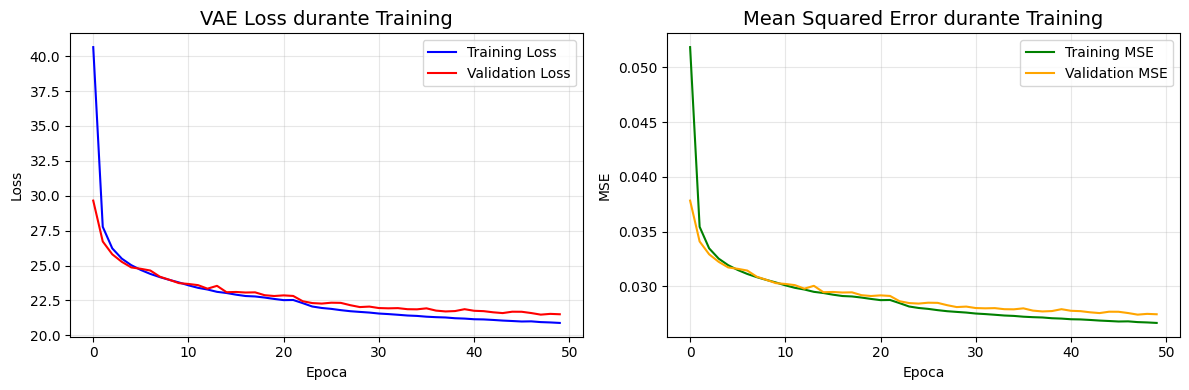


📊 Statistiche Training:
Loss finale training: 20.8929
Loss finale validation: 21.5139
Miglior validation loss: 21.4870 (epoca 48)
Differenza train-val: 0.6210


In [8]:
# CELLA 8 - ANALISI PERFORMANCE TRAINING
# Visualizzazione andamento training
print("📈 Analisi andamento training...")  # Messaggio analisi performance

# Creazione grafici training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Crea figura con 2 subplot affiancati

# Grafico 1: Loss durante training
axes[0].plot(history.history['loss'], label='Training Loss', color='blue')  # Plot loss training
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red')  # Plot loss validation
axes[0].set_title('VAE Loss durante Training', fontsize=14)  # Titolo grafico loss
axes[0].set_xlabel('Epoca')  # Etichetta asse X (epoche)
axes[0].set_ylabel('Loss')   # Etichetta asse Y (valore loss)
axes[0].legend()             # Mostra legenda grafico
axes[0].grid(True, alpha=0.3)  # Griglia trasparente per leggibilità

# Grafico 2: MSE durante training (metrica aggiuntiva)
axes[1].plot(history.history['mse'], label='Training MSE', color='green')      # Plot MSE training
axes[1].plot(history.history['val_mse'], label='Validation MSE', color='orange')  # Plot MSE validation
axes[1].set_title('Mean Squared Error durante Training', fontsize=14)  # Titolo grafico MSE
axes[1].set_xlabel('Epoca')  # Etichetta asse X
axes[1].set_ylabel('MSE')    # Etichetta asse Y (valore MSE)
axes[1].legend()             # Mostra legenda
axes[1].grid(True, alpha=0.3)  # Griglia trasparente

plt.tight_layout()  # Ottimizza layout per evitare sovrapposizioni
plt.show()  # Mostra grafici

# Statistiche finali training
final_train_loss = history.history['loss'][-1]      # Loss finale training (ultima epoca)
final_val_loss = history.history['val_loss'][-1]    # Loss finale validation (ultima epoca)
best_val_loss = min(history.history['val_loss'])    # Miglior validation loss raggiunto
best_epoch = history.history['val_loss'].index(best_val_loss) + 1  # Epoca con miglior validation loss

print(f"\n📊 Statistiche Training:")  # Intestazione statistiche
print(f"Loss finale training: {final_train_loss:.4f}")  # Stampa loss training finale
print(f"Loss finale validation: {final_val_loss:.4f}")  # Stampa loss validation finale
print(f"Miglior validation loss: {best_val_loss:.4f} (epoca {best_epoch})")  # Miglior performance
print(f"Differenza train-val: {abs(final_train_loss - final_val_loss):.4f}")  # Gap overfitting

## **Descrizione Cella 9:**


Testa le capacità del VAE nel ricostruire dati normali vs anomali, calcola errori di ricostruzione, definisce soglie per classificazione e computa metriche standard (precision, recall, F1-score) per valutare l'efficacia del sistema di anomaly detection.

In [9]:
# CELLA 9 - TEST RICOSTRUZIONE DATI NORMALI
# Test delle capacità di ricostruzione su dati normali e anomali
print("🔍 Test ricostruzione VAE...")  # Messaggio inizio test

# Ricostruzione dati Fashion MNIST (normali) - campione test
print("👕 Ricostruzione Fashion MNIST (dati normali)...")  # Messaggio test dati normali
fashion_reconstructed = vae.predict(x_test_fashion[:1000])  # Predizione su primi 1000 campioni test
fashion_errors = np.mean(np.square(x_test_fashion[:1000] - fashion_reconstructed), axis=1)  # Calcola MSE per ogni campione

# Ricostruzione MNIST digits (anomalie)
print("🔢 Ricostruzione MNIST Digits (anomalie)...")  # Messaggio test anomalie
anomalies_reconstructed = vae.predict(x_anomalies)  # Predizione sulle 10 anomalie selezionate
anomaly_errors = np.mean(np.square(x_anomalies - anomalies_reconstructed), axis=1)  # MSE per ogni anomalia

# Statistiche errori di ricostruzione
print(f"\n📊 Statistiche Errori di Ricostruzione:")  # Intestazione statistiche errori
print(f"Fashion MNIST (normali):")  # Sezione dati normali
print(f"  - Media: {np.mean(fashion_errors):.6f}")  # Media errori dati normali
print(f"  - Deviazione standard: {np.std(fashion_errors):.6f}")  # Deviazione standard normali
print(f"  - Min: {np.min(fashion_errors):.6f}")  # Errore minimo normali
print(f"  - Max: {np.max(fashion_errors):.6f}")  # Errore massimo normali

print(f"\nMNIST Digits (anomalie):")  # Sezione anomalie
print(f"  - Media: {np.mean(anomaly_errors):.6f}")  # Media errori anomalie
print(f"  - Deviazione standard: {np.std(anomaly_errors):.6f}")  # Deviazione standard anomalie
print(f"  - Min: {np.min(anomaly_errors):.6f}")  # Errore minimo anomalie
print(f"  - Max: {np.max(anomaly_errors):.6f}")  # Errore massimo anomalie

# Calcolo soglia di anomalia basata sui dati normali
threshold_1 = np.mean(fashion_errors)  # Soglia semplice = media errori normali
print(f"\n🎯 Soglia anomalia calcolata: {threshold_1:.6f}")  # Stampa soglia calcolata

# Calcolo soglia di anomalia basata sui dati statistici
threshold_factor = 2  # Fattore moltiplicativo per deviazione standard
threshold = np.mean(fashion_errors) + threshold_factor * np.std(fashion_errors)  # Soglia = media + 2*std

# Classificazione in base alla soglia
normal_above_threshold = np.sum(fashion_errors > threshold)    # Conta falsi positivi
anomalies_above_threshold = np.sum(anomaly_errors > threshold)  # Conta veri positivi

print(f"\n🎯 Risultati Classificazione:")  # Intestazione risultati
print(f"Dati normali sopra soglia (falsi positivi): {normal_above_threshold}/1000 ({normal_above_threshold/10:.1f}%)")  # Percentuale falsi positivi
print(f"Anomalie sopra soglia (veri positivi): {anomalies_above_threshold}/10 ({anomalies_above_threshold*10:.1f}%)")  # Percentuale veri positivi

# Calcolo metriche di performance
true_positives = anomalies_above_threshold     # Anomalie correttamente identificate
false_positives = normal_above_threshold       # Normali erroneamente classificate come anomalie
true_negatives = 1000 - normal_above_threshold # Normali correttamente identificate
false_negatives = 10 - anomalies_above_threshold  # Anomalie non identificate

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0  # Precision = TP/(TP+FP)
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0  # Recall = TP/(TP+FN)
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0  # F1-Score armonico

print(f"\n📊 Metriche Performance:")  # Intestazione metriche
print(f"Precision: {precision:.3f}")  # Stampa precisione
print(f"Recall: {recall:.3f}")        # Stampa richiamo
print(f"F1-Score: {f1_score:.3f}")    # Stampa F1 score

🔍 Test ricostruzione VAE...
👕 Ricostruzione Fashion MNIST (dati normali)...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
🔢 Ricostruzione MNIST Digits (anomalie)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

📊 Statistiche Errori di Ricostruzione:
Fashion MNIST (normali):
  - Media: 0.027118
  - Deviazione standard: 0.017253
  - Min: 0.004138
  - Max: 0.167777

MNIST Digits (anomalie):
  - Media: 0.079785
  - Deviazione standard: 0.015475
  - Min: 0.054830
  - Max: 0.099500

🎯 Soglia anomalia calcolata: 0.027118

🎯 Risultati Classificazione:
Dati normali sopra soglia (falsi positivi): 47/1000 (4.7%)
Anomalie sopra soglia (veri positivi): 8/10 (80.0%)

📊 Metriche Performance:
Precision: 0.145
Recall: 0.800
F1-Score: 0.246


## **Descrizione Cella 10:**


Visualizza i risultati dell'anomaly detection attraverso una griglia comparativa che mostra originali vs ricostruzioni per dati normali e anomali, utilizzando codifica colore per indicare la classificazione basata sulla soglia calcolata.

🖼️ Visualizzazione confronto ricostruzioni...


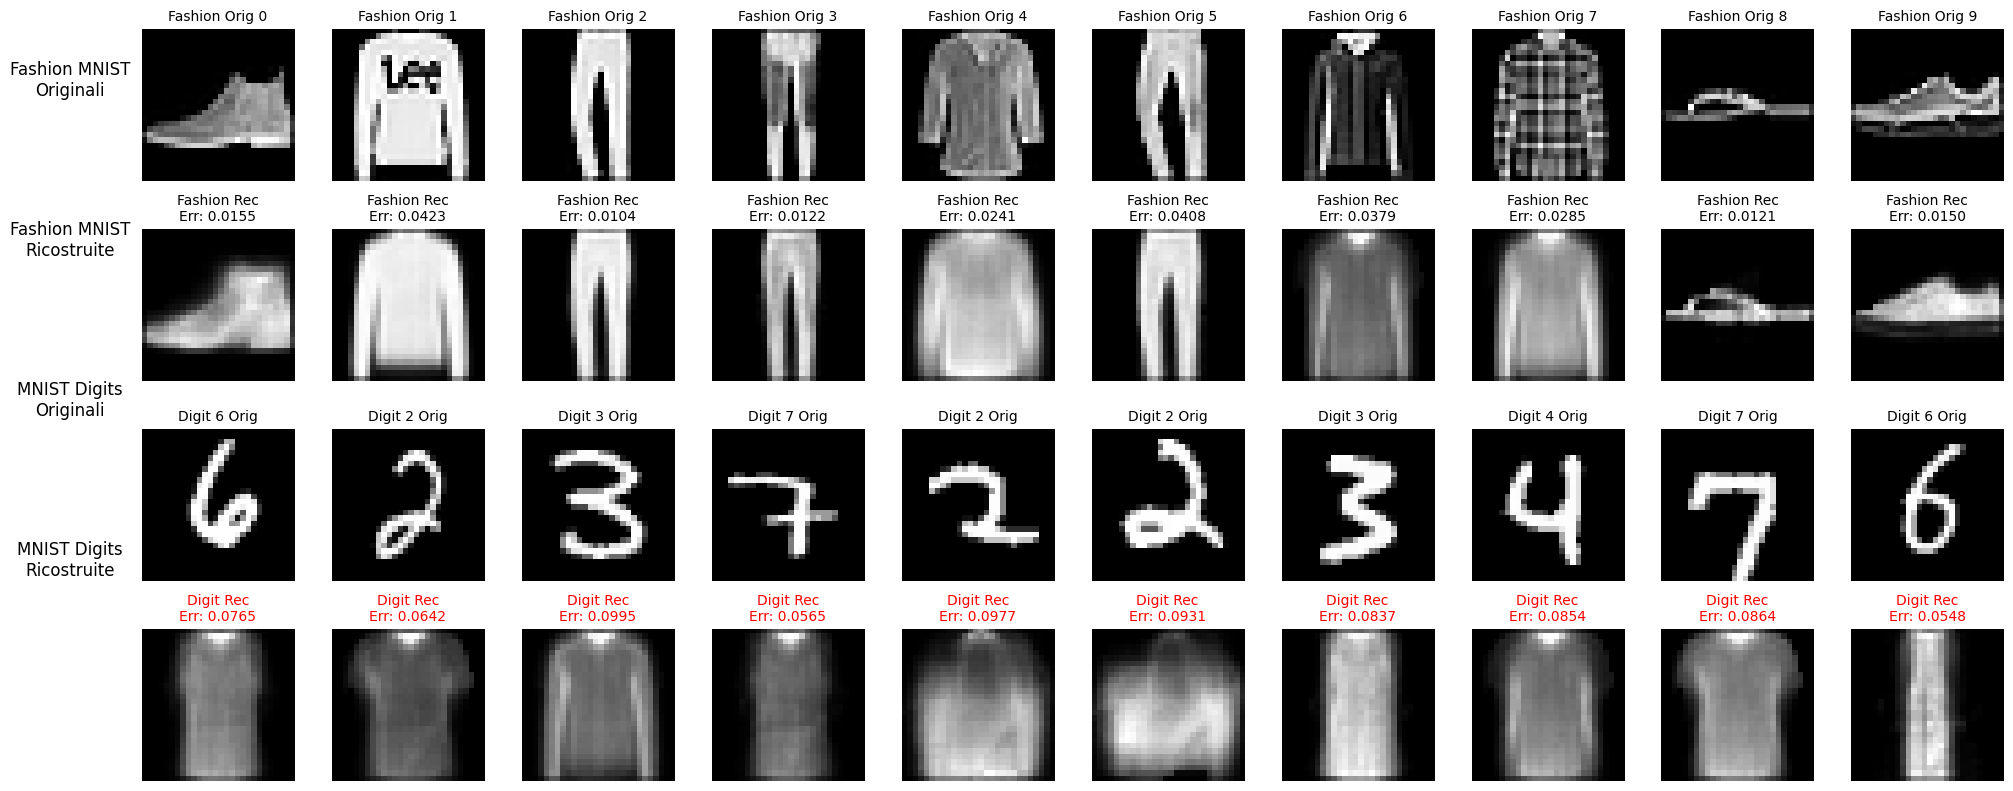

🎯 Soglia anomalia: 0.027118
🔴 = Classificato come anomalia | 🟢 = Classificato come normale (indicato dal colore del titolo)


In [10]:
# CELLA 10 - TEST FINALE CON INDIVIDUAZIONE ANOMALIE
# Visualizzazione confronto tra originali e ricostruzioni
print("🖼️ Visualizzazione confronto ricostruzioni...")  # Messaggio visualizzazione

# Creazione griglia di visualizzazione 4x10
fig, axes = plt.subplots(4, 10, figsize=(20, 8))  # Griglia 4 righe x 10 colonne

# Prima riga: Fashion MNIST originali (primi 10 del test set)
for i in range(10):  # Loop per prime 10 immagini
    axes[0, i].imshow(x_test_fashion[i].reshape(28, 28), cmap='gray')  # Mostra immagine originale 28x28
    axes[0, i].set_title(f'Fashion Orig {i}', fontsize=10)  # Titolo con indice immagine
    axes[0, i].axis('off')  # Rimuove assi per pulizia visuale

# Seconda riga: Fashion MNIST ricostruite
for i in range(10):  # Loop per ricostruzioni Fashion
    axes[1, i].imshow(fashion_reconstructed[i].reshape(28, 28), cmap='gray')  # Mostra ricostruzione
    error = fashion_errors[i]  # Ottiene errore di ricostruzione per questo campione
    axes[1, i].set_title(f'Fashion Rec\nErr: {error:.4f}', fontsize=10)  # Titolo con errore
    axes[1, i].axis('off')  # Rimuove assi

# Terza riga: MNIST Digits originali (anomalie)
for i in range(10):  # Loop per anomalie originali
    axes[2, i].imshow(x_anomalies[i].reshape(28, 28), cmap='gray')  # Mostra anomalia originale
    axes[2, i].set_title(f'Digit {y_anomalies[i]} Orig', fontsize=10)  # Titolo con etichetta digit
    axes[2, i].axis('off')  # Rimuove assi

# Quarta riga: MNIST Digits ricostruite
for i in range(10):  # Loop per ricostruzioni anomalie
    axes[3, i].imshow(anomalies_reconstructed[i].reshape(28, 28), cmap='gray')  # Mostra ricostruzione anomalia
    error = anomaly_errors[i]  # Ottiene errore di ricostruzione anomalia
    # Determina il colore del titolo in base alla classificazione
    title_color = 'red' if error > threshold_1 else 'green'  # Rosso se sopra soglia (anomalia), verde altrimenti
    axes[3, i].set_title(f'Digit Rec\nErr: {error:.4f}', fontsize=10, color=title_color)  # Titolo colorato con errore
    axes[3, i].axis('off')  # Rimuove assi

# Etichette per le righe
fig.text(0.02, 0.875, 'Fashion MNIST\nOriginali', fontsize=12, ha='center')     # Etichetta riga 1
fig.text(0.02, 0.675, 'Fashion MNIST\nRicostruite', fontsize=12, ha='center')   # Etichetta riga 2
fig.text(0.02, 0.475, 'MNIST Digits\nOriginali', fontsize=12, ha='center')      # Etichetta riga 3
fig.text(0.02, 0.275, 'MNIST Digits\nRicostruite', fontsize=12, ha='center')    # Etichetta riga 4

plt.tight_layout()  # Ottimizza layout per evitare sovrapposizioni
plt.subplots_adjust(left=0.05)  # Lascia spazio per etichette a sinistra
plt.show()  # Mostra il grafico completo

print(f"🎯 Soglia anomalia: {threshold_1:.6f}")  # Stampa soglia utilizzata
print(f"🔴 = Classificato come anomalia | 🟢 = Classificato come normale (indicato dal colore del titolo)")  # Legenda colori

## **Descrizione Cella 11:**


Questa cella implementa laconversione del modello VAE in formato TensorFlow Lite (TFLite) per deployment su dispositivi con risorse limitate. Carica il modello SavedModel precedentemente salvato, crea un converter TFLite e genera un file .tflite ottimizzato. Include gestione completa degli errori per robustezza e feedback dettagliato del processo.

In [11]:
# CELLA 11 - CONVERSIONE IN TFLITE
# Applicazione della riduzione TFLite al modello VAE
print("📦 Conversione del modello VAE in formato TFLite...")  # Messaggio inizio conversione

# Caricamento del modello VAE salvato (SavedModel)
# Assicurati che la cartella 'vae_fashion_mnist_savedmodel' esista e contenga il modello salvato
try:
    loaded_vae = tf.saved_model.load('vae_fashion_mnist_savedmodel')  # Carica modello SavedModel da directory
    print("✅ Modello VAE caricato correttamente.")  # Conferma caricamento riuscito
except Exception as e:  # Gestione errori di caricamento
    print(f"❌ Errore nel caricamento del modello: {e}")  # Stampa messaggio errore
    loaded_vae = None  # Imposta variabile a None per controlli successivi

if loaded_vae:  # Procede solo se caricamento riuscito
    # Creazione del TFLite Converter
    converter = tf.lite.TFLiteConverter.from_saved_model('vae_fashion_mnist_savedmodel')  # Crea converter da SavedModel

    # (Opzionale) Applica ottimizzazioni (es. quantizzazione)
    # converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Riga commentata per ottimizzazioni future
    # print("✨ Ottimizzazioni TFLite abilitate.")  # Messaggio ottimizzazioni (commentato)

    # Conversione del modello
    try:
        tflite_model = converter.convert()  # Esegue conversione da SavedModel a TFLite
        print("✅ Conversione in TFLite completata.")  # Conferma conversione riuscita

        # Salvataggio del modello TFLite
        tflite_model_path = 'vae_fashion_mnist.tflite'  # Definisce percorso file TFLite
        with open(tflite_model_path, 'wb') as f:  # Apre file in modalità scrittura binaria
            f.write(tflite_model)  # Scrive bytes del modello TFLite su file

        print(f"💾 Modello TFLite salvato in: {tflite_model_path}")  # Conferma salvataggio con percorso

    except Exception as e:  # Gestione errori durante conversione/salvataggio
        print(f"❌ Errore durante la conversione o il salvataggio del modello TFLite: {e}")  # Messaggio errore dettagliato

else:
    print("🚫 Conversione TFLite annullata a causa dell'errore nel caricamento del modello.")  # Messaggio fallimento pipeline

📦 Conversione del modello VAE in formato TFLite...
✅ Modello VAE caricato correttamente.
✅ Conversione in TFLite completata.
💾 Modello TFLite salvato in: vae_fashion_mnist.tflite


## **Descrizione Cella 12:**


Questa cella analizza l'efficienza della conversione TFLite calcolando e confrontando le dimensioni del modello prima (SavedModel) e dopo (TFLite) la conversione. Implementa una funzione personalizzata per calcolo ricorsivo delle dimensioni delle directory e presenta i risultati in formato user-friendly con conversione da bytes a MB e calcolo della percentuale di riduzione.

In [12]:
# CELLA 12 - CALCOLO MEMORIA MODELLO VAE PRE TFLITE E POST
import os  # Libreria per operazioni su filesystem

# Funzione per calcolare la dimensione di una cartella
def get_dir_size(path='.'):
    """Calcola ricorsivamente la dimensione totale di una directory"""
    total_size = 0  # Inizializza contatore dimensione totale
    for dirpath, dirnames, filenames in os.walk(path):  # Attraversa ricorsivamente directory
        for f in filenames:  # Per ogni file nella directory corrente
            fp = os.path.join(dirpath, f)  # Crea percorso completo file
            total_size += os.path.getsize(fp)  # Aggiunge dimensione file al totale
    return total_size  # Ritorna dimensione totale in bytes

# Percorsi dei modelli salvati
saved_model_path = 'vae_fashion_mnist_savedmodel'  # Path directory SavedModel
tflite_model_path = 'vae_fashion_mnist.tflite'  # Path file TFLite

print("📏 Calcolo memoria occupata dai modelli...")  # Messaggio inizio calcolo dimensioni

# Dimensione del modello pre-TFLite (SavedModel)
try:
    pre_tflite_size = get_dir_size(saved_model_path)  # Calcola dimensione directory SavedModel
    print(f"💾 Memoria occupata dal modello pre-TFLite (SavedModel): {pre_tflite_size / (1024*1024):.2f} MB")  # Converti bytes in MB
except Exception as e:  # Gestione errori calcolo SavedModel
    print(f"❌ Errore nel calcolo della dimensione del SavedModel: {e}")  # Messaggio errore
    pre_tflite_size = None  # Imposta a None per controlli successivi

# Dimensione del modello post-TFLite (file .tflite)
try:
    post_tflite_size = os.path.getsize(tflite_model_path)  # Ottiene dimensione file TFLite
    print(f"💾 Memoria occupata dal modello post-TFLite (.tflite): {post_tflite_size / (1024*1024):.2f} MB")  # Converti bytes in MB
except Exception as e:  # Gestione errori calcolo TFLite
    print(f"❌ Errore nel calcolo della dimensione del file TFLite: {e}")  # Messaggio errore
    post_tflite_size = None  # Imposta a None per controlli successivi

# Calcolo percentuale di riduzione se entrambe le dimensioni sono disponibili
if pre_tflite_size is not None and post_tflite_size is not None:  # Controlla che entrambi i valori esistano
    reduction_percentage = ((pre_tflite_size - post_tflite_size) / pre_tflite_size) * 100  # Calcola percentuale riduzione
    print(f"📉 Riduzione della memoria: {reduction_percentage:.2f}%")  # Stampa percentuale di riduzione

📏 Calcolo memoria occupata dai modelli...
💾 Memoria occupata dal modello pre-TFLite (SavedModel): 3.15 MB
💾 Memoria occupata dal modello post-TFLite (.tflite): 1.55 MB
📉 Riduzione della memoria: 50.97%


## **Descrizione Cella 13:**


Implementa la quantizzazione del modello TFLite per ulteriore riduzione delle dimensioni e miglioramento delle performance su dispositivi edge. Utilizza tf.lite.Optimize.DEFAULT per quantizzazione dinamica dei pesi, confronta le dimensioni pre/post quantizzazione e fornisce metriche dettagliate sulla compressione ottenuta.

In [13]:
# CELLA 13 - APPLICAZIONE QUANTIZZAZIONE AL MODELLO VAE TFLITE
# Applicazione della quantizzazione al modello VAE TFLite
print("✨ Applicazione della quantizzazione al modello TFLite...")  # Messaggio inizio quantizzazione

# Caricamento del modello VAE salvato (SavedModel)
try:
    loaded_vae = tf.saved_model.load('vae_fashion_mnist_savedmodel')  # Ricarica modello SavedModel
    print("✅ Modello VAE caricato correttamente.")  # Conferma caricamento per quantizzazione
except Exception as e:  # Gestione errori caricamento
    print(f"❌ Errore nel caricamento del modello SavedModel per quantizzazione: {e}")  # Messaggio errore dettagliato
    loaded_vae = None  # Imposta a None per controlli pipeline

if loaded_vae:  # Procede solo se caricamento riuscito
    # Creazione del TFLite Converter dal SavedModel
    converter = tf.lite.TFLiteConverter.from_saved_model('vae_fashion_mnist_savedmodel')  # Crea nuovo converter

    # Abilita le ottimizzazioni predefinite (inclusa la quantizzazione a intervallo dinamico)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Attiva ottimizzazioni TFLite (quantizzazione dinamica)
    print("✅ Ottimizzazioni TFLite (inclusa quantizzazione) abilitate.")  # Conferma attivazione ottimizzazioni

    # Conversione del modello con ottimizzazioni
    try:
        tflite_quantized_model = converter.convert()  # Esegue conversione con quantizzazione
        print("✅ Conversione in TFLite quantizzato completata.")  # Conferma conversione quantizzata

        # Salvataggio del modello TFLite quantizzato
        tflite_quantized_model_path = 'vae_fashion_mnist_quantized.tflite'  # Path file quantizzato
        with open(tflite_quantized_model_path, 'wb') as f:  # Apre file in modalità scrittura binaria
            f.write(tflite_quantized_model)  # Scrive bytes modello quantizzato

        print(f"💾 Modello TFLite quantizzato salvato in: {tflite_quantized_model_path}")  # Conferma salvataggio

        # (Opzionale) Confronto dimensioni
        original_tflite_size = os.path.getsize('vae_fashion_mnist.tflite')  # Dimensione TFLite originale
        quantized_tflite_size = os.path.getsize(tflite_quantized_model_path)  # Dimensione TFLite quantizzato
        size_reduction = original_tflite_size - quantized_tflite_size  # Calcola riduzione assoluta
        reduction_percentage = (size_reduction / original_tflite_size) * 100 if original_tflite_size > 0 else 0  # Percentuale riduzione

        print(f"\n📊 Confronto Dimensioni:")  # Intestazione confronto
        print(f"Modello TFLite originale: {original_tflite_size / (1024*1024):.2f} MB")  # Dimensione originale in MB
        print(f"Modello TFLite quantizzato: {quantized_tflite_size / (1024*1024):.2f} MB")  # Dimensione quantizzata in MB
        print(f"Riduzione dimensione: {size_reduction / 1024:.2f} KB ({reduction_percentage:.2f}%)")  # Riduzione in KB e percentuale

    except Exception as e:  # Gestione errori conversione/salvataggio
        print(f"❌ Errore durante la conversione o il salvataggio del modello TFLite quantizzato: {e}")  # Messaggio errore

else:
    print("🚫 Quantizzazione TFLite annullata a causa dell'errore nel caricamento del modello.")  # Messaggio fallimento pipeline

✨ Applicazione della quantizzazione al modello TFLite...
✅ Modello VAE caricato correttamente.
✅ Ottimizzazioni TFLite (inclusa quantizzazione) abilitate.
✅ Conversione in TFLite quantizzato completata.
💾 Modello TFLite quantizzato salvato in: vae_fashion_mnist_quantized.tflite

📊 Confronto Dimensioni:
Modello TFLite originale: 1.55 MB
Modello TFLite quantizzato: 0.41 MB
Riduzione dimensione: 1163.81 KB (73.53%)


## **Descrizione Cella 14:**


Questa cella rappresenta la validazione finale del pipeline di ottimizzazione testando le performance del modello TFLite quantizzato. Implementa un interprete TFLite personalizzato che gestisce la quantizzazione/de-quantizzazione dei dati, esegue inferenza su dati normali e anomali, calcola metriche di performance (precision, recall, F1-score) e confronta visivamente i risultati con il modello originale per verificare che l'ottimizzazione non abbia compromesso la capacità di anomaly detection.

🔍 Esecuzione test di ricostruzione con modello VAE TFLite quantizzato...
✅ Modello TFLite quantizzato caricato e interprete creato.
👕 Ricostruzione Fashion MNIST (dati normali) con TFLite quantizzato...
🔢 Ricostruzione MNIST Digits (anomalie) con TFLite quantizzato...

📊 Statistiche Errori di Ricostruzione (Modello TFLite Quantizzato):
Fashion MNIST (normali):
  - Media: 0.027269
  - Deviazione standard: 0.017237
  - Min: 0.004150
  - Max: 0.167474

MNIST Digits (anomalie):
  - Media: 0.079716
  - Deviazione standard: 0.015416
  - Min: 0.054873
  - Max: 0.099374

🎯 Soglia anomalia calcolata (Modello TFLite Quantizzato): 0.027269

🎯 Risultati Classificazione (Modello TFLite Quantizzato):
Dati normali sopra soglia (falsi positivi): 46/1000 (4.6%)
Anomalie sopra soglia (veri positivi): 8/10 (80.0%)

📊 Metriche Performance (Modello TFLite Quantizzato):
Precision: 0.148
Recall: 0.800
F1-Score: 0.250

🖼️ Visualizzazione confronto ricostruzioni (Modello TFLite Quantizzato)...


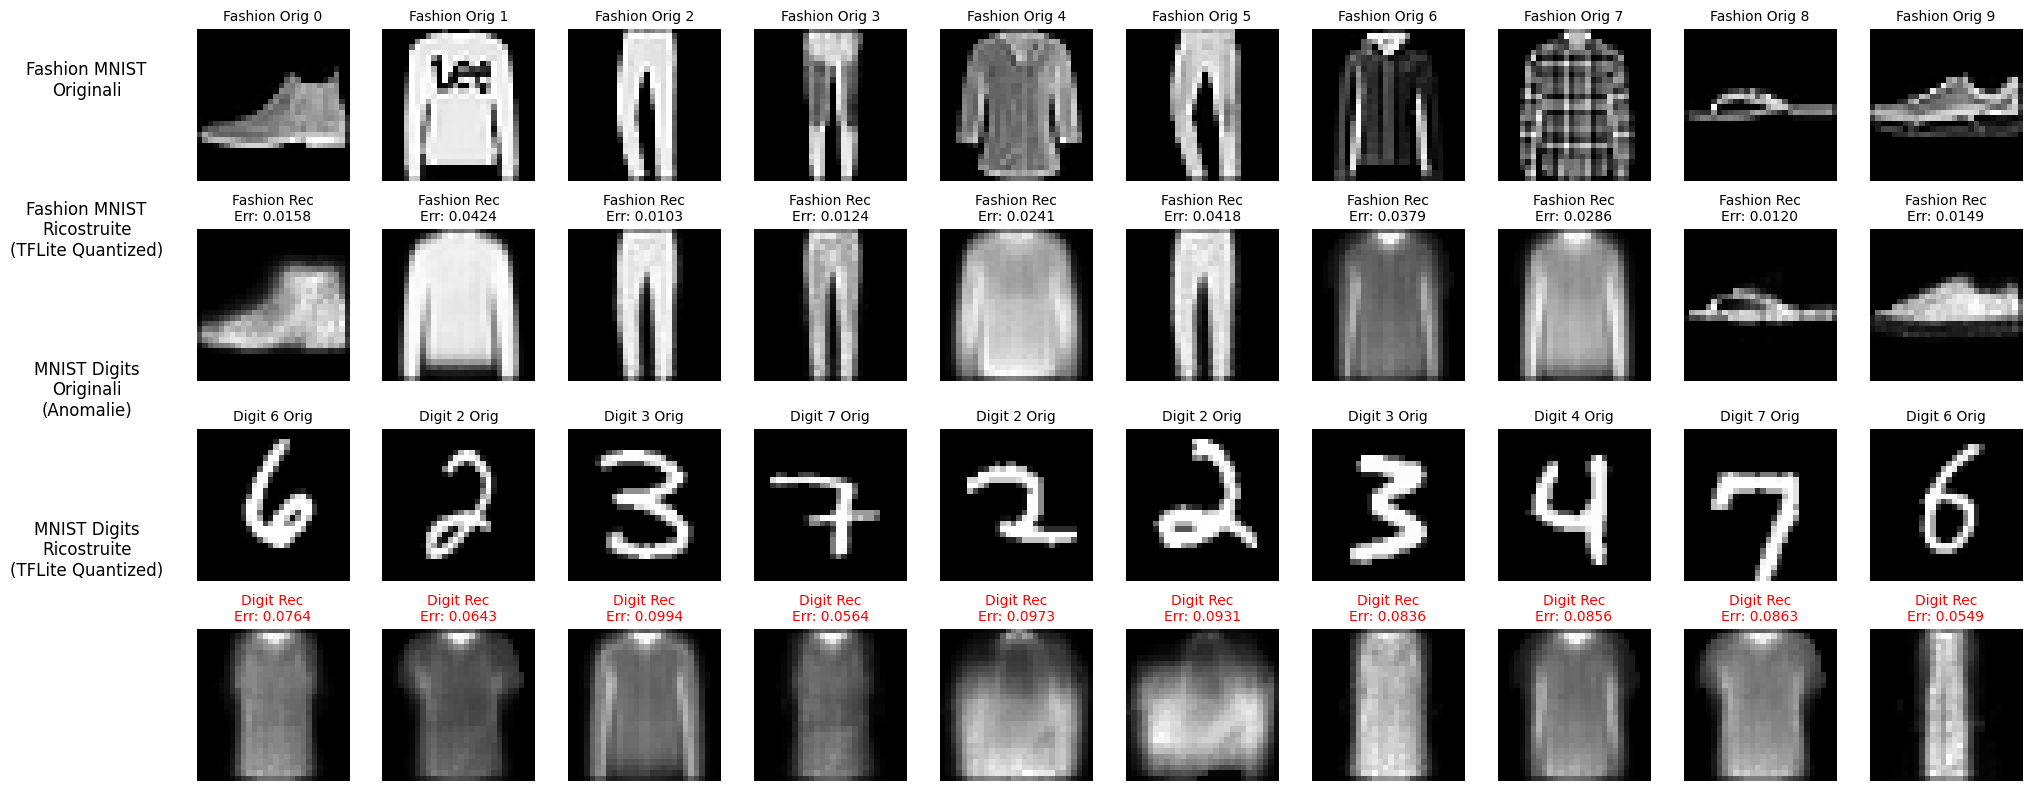

🎯 Soglia anomalia (Modello TFLite Quantizzato): 0.027269
🔴 = Classificato come anomalia | 🟢 = Classificato come normale (indicato dal colore del titolo)


In [14]:
# CELLA 14 - TEST DI RICOSTRUZIONE CON MODELLO TFLITE QUANTIZZATO
# Esegue il test di ricostruzione utilizzando il modello VAE TFLite quantizzato
print("🔍 Esecuzione test di ricostruzione con modello VAE TFLite quantizzato...")  # Messaggio inizio test

# Percorso del modello TFLite quantizzato
tflite_quantized_model_path = 'vae_fashion_mnist_quantized.tflite'  # Path modello quantizzato

# Caricamento del modello TFLite e creazione dell'interprete
try:
    interpreter_quantized = tf.lite.Interpreter(model_path=tflite_quantized_model_path)  # Crea interprete TFLite
    interpreter_quantized.allocate_tensors()  # Alloca memoria per tensori input/output

    # Ottieni i dettagli dei tensori di input e output
    input_details_quantized = interpreter_quantized.get_input_details()  # Dettagli tensore input
    output_details_quantized = interpreter_quantized.get_output_details()  # Dettagli tensore output

    print("✅ Modello TFLite quantizzato caricato e interprete creato.")  # Conferma inizializzazione

except Exception as e:  # Gestione errori caricamento/inizializzazione
    print(f"❌ Errore nel caricamento o inizializzazione dell'interprete TFLite quantizzato: {e}")  # Messaggio errore
    interpreter_quantized = None  # Imposta a None per controlli pipeline

if interpreter_quantized:  # Procede solo se interprete inizializzato correttamente
    # Funzione helper per eseguire l'inferenza con il modello TFLite quantizzato
    def run_tflite_inference_quantized(interpreter, input_data):
        """Esegue l'inferenza per un dato input utilizzando l'interprete TFLite quantizzato."""
        # Prepara l'input in base al tipo di dati del tensore di input quantizzato (solitamente int8)
        input_dtype = input_details_quantized[0]['dtype']  # Ottiene tipo dati input tensor
        if input_dtype == np.int8:  # Se input richiede quantizzazione int8
            input_scale, input_zero_point = input_details_quantized[0]['quantization']  # Parametri quantizzazione input
            input_data = input_data / input_scale + input_zero_point  # Applica quantizzazione input
            input_data = input_data.astype(input_dtype)  # Converti al tipo richiesto

        interpreter.set_tensor(input_details_quantized[0]['index'], input_data)  # Imposta tensor input
        interpreter.invoke()  # Esegue inferenza
        output_data = interpreter.get_tensor(output_details_quantized[0]['index'])  # Ottiene tensor output

        # De-quantizza l'output se necessario (solitamente float32 per la ricostruzione)
        output_dtype = output_details_quantized[0]['dtype']  # Tipo dati output tensor
        if output_dtype == np.int8:  # Se output è quantizzato int8
             output_scale, output_zero_point = output_details_quantized[0]['quantization']  # Parametri quantizzazione output
             output_data = (output_data - output_zero_point) * output_scale  # De-quantizza output
             output_data = output_data.astype(np.float32)  # Converti in float32 per calcoli successivi

        return output_data  # Ritorna dati ricostruiti

    # Ricostruzione dati Fashion MNIST (normali) - campione test (primi 1000)
    print("👕 Ricostruzione Fashion MNIST (dati normali) con TFLite quantizzato...")  # Messaggio test normali
    fashion_reconstructed_tflite_quantized = []  # Lista per ricostruzioni Fashion MNIST
    for img in x_test_fashion[:1000]:  # Loop sui primi 1000 campioni test
        # TFLite richiede input in batch, anche per un singolo elemento
        img_batch = np.expand_dims(img, axis=0)  # Aggiunge dimensione batch [784] -> [1, 784]
        reconstructed_img = run_tflite_inference_quantized(interpreter_quantized, img_batch)  # Esegue inferenza
        fashion_reconstructed_tflite_quantized.append(reconstructed_img[0])  # Rimuove dimensione batch e salva

    fashion_reconstructed_tflite_quantized = np.array(fashion_reconstructed_tflite_quantized)  # Converti lista in array
    fashion_errors_tflite_quantized = np.mean(np.square(x_test_fashion[:1000] - fashion_reconstructed_tflite_quantized), axis=1)  # Calcola MSE per campione

    # Ricostruzione MNIST digits (anomalie)
    print("🔢 Ricostruzione MNIST Digits (anomalie) con TFLite quantizzato...")  # Messaggio test anomalie
    anomalies_reconstructed_tflite_quantized = []  # Lista per ricostruzioni anomalie
    for img in x_anomalies:  # Loop sulle 10 anomalie
        # TFLite richiede input in batch, anche per un singolo elemento
        img_batch = np.expand_dims(img, axis=0)  # Aggiunge dimensione batch
        reconstructed_img = run_tflite_inference_quantized(interpreter_quantized, img_batch)  # Inferenza
        anomalies_reconstructed_tflite_quantized.append(reconstructed_img[0])  # Salva senza dimensione batch

    anomalies_reconstructed_tflite_quantized = np.array(anomalies_reconstructed_tflite_quantized)  # Converti in array
    anomaly_errors_tflite_quantized = np.mean(np.square(x_anomalies - anomalies_reconstructed_tflite_quantized), axis=1)  # MSE anomalie

    # Statistiche errori di ricostruzione (da modello TFLite quantizzato)
    print(f"\n📊 Statistiche Errori di Ricostruzione (Modello TFLite Quantizzato):")  # Intestazione statistiche
    print(f"Fashion MNIST (normali):")  # Sezione dati normali
    print(f"  - Media: {np.mean(fashion_errors_tflite_quantized):.6f}")  # Media errori normali
    print(f"  - Deviazione standard: {np.std(fashion_errors_tflite_quantized):.6f}")  # Std errori normali
    print(f"  - Min: {np.min(fashion_errors_tflite_quantized):.6f}")  # Errore minimo normali
    print(f"  - Max: {np.max(fashion_errors_tflite_quantized):.6f}")  # Errore massimo normali

    print(f"\nMNIST Digits (anomalie):")  # Sezione anomalie
    print(f"  - Media: {np.mean(anomaly_errors_tflite_quantized):.6f}")  # Media errori anomalie
    print(f"  - Deviazione standard: {np.std(anomaly_errors_tflite_quantized):.6f}")  # Std errori anomalie
    print(f"  - Min: {np.min(anomaly_errors_tflite_quantized):.6f}")  # Errore minimo anomalie
    print(f"  - Max: {np.max(anomaly_errors_tflite_quantized):.6f}")  # Errore massimo anomalie

    # Calcolo soglia di anomalia basata sui dati normali (dal modello TFLite quantizzato)
    # Utilizziamo la stessa logica di soglia per confronto
    # Assicurati che threshold_factor sia definito nel notebook (dovrebbe essere dalla Cella 9)
    try:
        threshold_factor_val = threshold_factor  # Usa variabile globale se definita
    except NameError:  # Se variabile non definita
        threshold_factor_val = 2  # Usa valore di default

    threshold_tflite_quantized_1 = np.mean(fashion_errors_tflite_quantized)  # Soglia semplice = media
    print(f"\n🎯 Soglia anomalia calcolata (Modello TFLite Quantizzato): {threshold_tflite_quantized_1:.6f}")  # Stampa soglia

    threshold_tflite_quantized = np.mean(fashion_errors_tflite_quantized) + threshold_factor_val * np.std(fashion_errors_tflite_quantized)  # Soglia = media + k*std

    # Classificazione in base alla soglia (con errori TFLite quantizzati)
    normal_above_threshold_tflite_quantized = np.sum(fashion_errors_tflite_quantized > threshold_tflite_quantized)  # Conta falsi positivi
    anomalies_above_threshold_tflite_quantized = np.sum(anomaly_errors_tflite_quantized > threshold_tflite_quantized)  # Conta veri positivi

    print(f"\n🎯 Risultati Classificazione (Modello TFLite Quantizzato):")  # Intestazione risultati
    print(f"Dati normali sopra soglia (falsi positivi): {normal_above_threshold_tflite_quantized}/1000 ({normal_above_threshold_tflite_quantized/10:.1f}%)")  # Percentuale falsi positivi
    print(f"Anomalie sopra soglia (veri positivi): {anomalies_above_threshold_tflite_quantized}/10 ({anomalies_above_threshold_tflite_quantized*10:.1f}%)")  # Percentuale veri positivi

    # Calcolo metriche di performance (con risultati TFLite quantizzati)
    true_positives_tflite_quantized = anomalies_above_threshold_tflite_quantized  # Anomalie correttamente rilevate
    false_positives_tflite_quantized = normal_above_threshold_tflite_quantized  # Normali classificate erroneamente
    true_negatives_tflite_quantized = 1000 - normal_above_threshold_tflite_quantized  # Normali classificate correttamente
    false_negatives_tflite_quantized = 10 - anomalies_above_threshold_tflite_quantized  # Anomalie non rilevate

    # Calcolo precision = TP/(TP+FP)
    precision_tflite_quantized = true_positives_tflite_quantized / (true_positives_tflite_quantized + false_positives_tflite_quantized) if (true_positives_tflite_quantized + false_positives_tflite_quantized) > 0 else 0
    # Calcolo recall = TP/(TP+FN)
    recall_tflite_quantized = true_positives_tflite_quantized / (true_positives_tflite_quantized + false_negatives_tflite_quantized) if (true_positives_tflite_quantized + false_negatives_tflite_quantized) > 0 else 0
    # Calcolo F1-score = 2*(precision*recall)/(precision+recall)
    f1_score_tflite_quantized = 2 * (precision_tflite_quantized * recall_tflite_quantized) / (precision_tflite_quantized + recall_tflite_quantized) if (precision_tflite_quantized + recall_tflite_quantized) > 0 else 0

    print(f"\n📊 Metriche Performance (Modello TFLite Quantizzato):")  # Intestazione metriche
    print(f"Precision: {precision_tflite_quantized:.3f}")  # Stampa precision
    print(f"Recall: {recall_tflite_quantized:.3f}")  # Stampa recall
    print(f"F1-Score: {f1_score_tflite_quantized:.3f}")  # Stampa F1-score

    # Visualizzazione confronto tra originali e ricostruzioni (utilizzando i risultati TFLite quantizzati)
    print("\n🖼️ Visualizzazione confronto ricostruzioni (Modello TFLite Quantizzato)...")  # Messaggio visualizzazione

    # Creazione griglia di visualizzazione 4x10
    fig, axes = plt.subplots(4, 10, figsize=(20, 8))  # Griglia 4 righe x 10 colonne

    # Prima riga: Fashion MNIST originali (primi 10 del test set)
    for i in range(10):  # Loop per primi 10 campioni
        axes[0, i].imshow(x_test_fashion[i].reshape(28, 28), cmap='gray')  # Mostra immagine originale 28x28
        axes[0, i].set_title(f'Fashion Orig {i}', fontsize=10)  # Titolo con indice
        axes[0, i].axis('off')  # Rimuove assi

    # Seconda riga: Fashion MNIST ricostruite (con TFLite quantizzato)
    for i in range(10):  # Loop per ricostruzioni Fashion
        axes[1, i].imshow(fashion_reconstructed_tflite_quantized[i].reshape(28, 28), cmap='gray')  # Mostra ricostruzione quantizzata
        error = fashion_errors_tflite_quantized[i]  # Errore ricostruzione quantizzata
        axes[1, i].set_title(f'Fashion Rec\nErr: {error:.4f}', fontsize=10)  # Titolo con errore
        axes[1, i].axis('off')  # Rimuove assi

    # Terza riga: MNIST Digits originali (anomalie)
    for i in range(10):  # Loop per anomalie originali
        axes[2, i].imshow(x_anomalies[i].reshape(28, 28), cmap='gray')  # Mostra anomalia originale
        axes[2, i].set_title(f'Digit {y_anomalies[i]} Orig', fontsize=10)  # Titolo con etichetta digit
        axes[2, i].axis('off')  # Rimuove assi

    # Quarta riga: MNIST Digits ricostruite (con TFLite quantizzato)
    for i in range(10):  # Loop per ricostruzioni anomalie
        axes[3, i].imshow(anomalies_reconstructed_tflite_quantized[i].reshape(28, 28), cmap='gray')  # Mostra ricostruzione anomalia quantizzata
        error = anomaly_errors_tflite_quantized[i]  # Errore ricostruzione anomalia
        # Determina il colore del titolo in base alla classificazione (con soglia TFLite quantizzata)
        title_color = 'red' if error > threshold_tflite_quantized_1 else 'green'  # Rosso se anomalia, verde se normale
        axes[3, i].set_title(f'Digit Rec\nErr: {error:.4f}', fontsize=10, color=title_color)  # Titolo colorato con errore
        axes[3, i].axis('off')  # Rimuove assi

    # Etichette per le righe
    fig.text(0.02, 0.875, 'Fashion MNIST\nOriginali', fontsize=12, ha='center')  # Etichetta riga 1
    fig.text(0.02, 0.675, 'Fashion MNIST\nRicostruite\n(TFLite Quantized)', fontsize=12, ha='center')  # Etichetta riga 2
    fig.text(0.02, 0.475, 'MNIST Digits\nOriginali\n(Anomalie)', fontsize=12, ha='center')  # Etichetta riga 3
    fig.text(0.02, 0.275, 'MNIST Digits\nRicostruite\n(TFLite Quantized)', fontsize=12, ha='center')  # Etichetta riga 4

    plt.tight_layout()  # Ottimizza layout
    plt.subplots_adjust(left=0.07)  # Aggiusta spazio per etichette più lunghe
    plt.show()  # Mostra grafico

    print(f"🎯 Soglia anomalia (Modello TFLite Quantizzato): {threshold_tflite_quantized_1:.6f}")  # Stampa soglia utilizzata
    print(f"🔴 = Classificato come anomalia | 🟢 = Classificato come normale (indicato dal colore del titolo)")  # Legenda colori

else:
    print("🚫 Impossibile eseguire il test di ricostruzione TFLite quantizzato a causa dell'errore nel caricamento del modello.")  # Messaggio fallimento pipeline